In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e1/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e1/train.csv
/kaggle/input/competitions/playground-series-s6e1/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e1/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e1/test.csv")

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                270000 non-null  int64  
 1   age               270000 non-null  int64  
 2   gender            270000 non-null  object 
 3   course            270000 non-null  object 
 4   study_hours       270000 non-null  float64
 5   class_attendance  270000 non-null  float64
 6   internet_access   270000 non-null  object 
 7   sleep_hours       270000 non-null  float64
 8   sleep_quality     270000 non-null  object 
 9   study_method      270000 non-null  object 
 10  facility_rating   270000 non-null  object 
 11  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.7+ MB


In [5]:
train.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


In [6]:
train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [7]:
train.isnull().sum()

id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

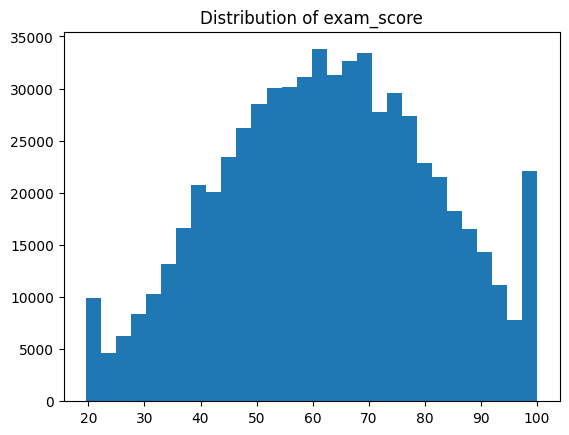

In [8]:
import matplotlib.pyplot as plt
plt.hist(train["exam_score"], bins=30)
plt.title("Distribution of exam_score")
plt.show()


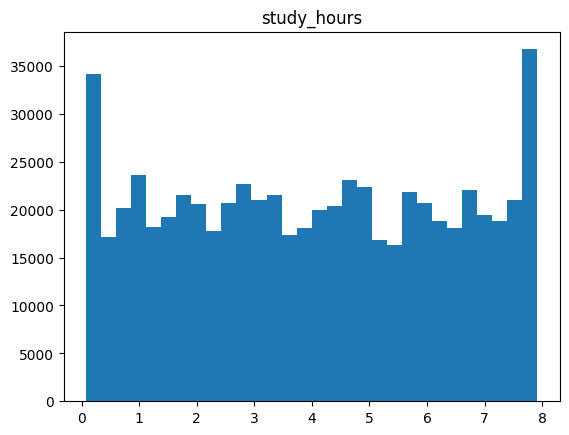

In [9]:
plt.hist(train["study_hours"], bins=30)
plt.title("study_hours")
plt.show()


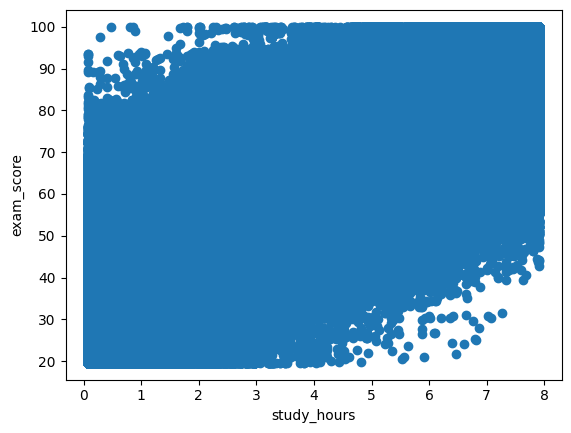

In [10]:
plt.scatter(train["study_hours"], train["exam_score"])
plt.xlabel("study_hours")
plt.ylabel("exam_score")
plt.show()


In [11]:
train.corr(numeric_only=True)


,id,age,study_hours,class_attendance,sleep_hours,exam_score
id,1.000000,-0.000581,0.000346,0.000677,0.001416,0.000372
age,-0.000581,1.000000,0.007545,0.005628,0.005864,0.010472
study_hours,0.000346,0.007545,1.000000,0.087617,0.042491,0.762267
class_attendance,0.000677,0.005628,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.001416,0.005864,0.042491,0.029263,1.000000,0.167410
exam_score,0.000372,0.010472,0.762267,0.360954,0.167410,1.000000


In [12]:
train["gender"].value_counts()


gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [13]:
X = train.drop("exam_score", axis=1)
y = train["exam_score"]

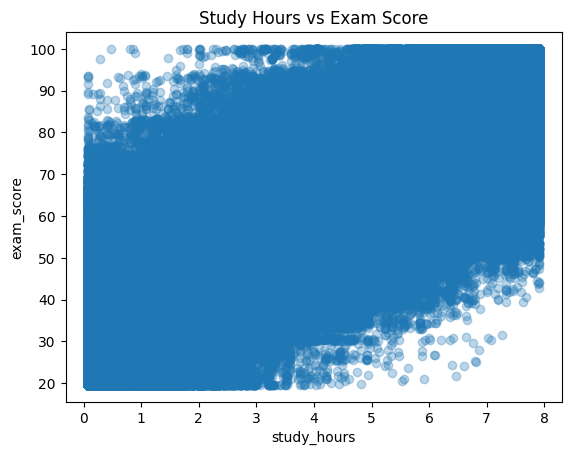

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.regplot(x="study_hours", y="exam_score", data=train, scatter_kws={"alpha":0.3})
plt.title("Study Hours vs Exam Score")
plt.show()


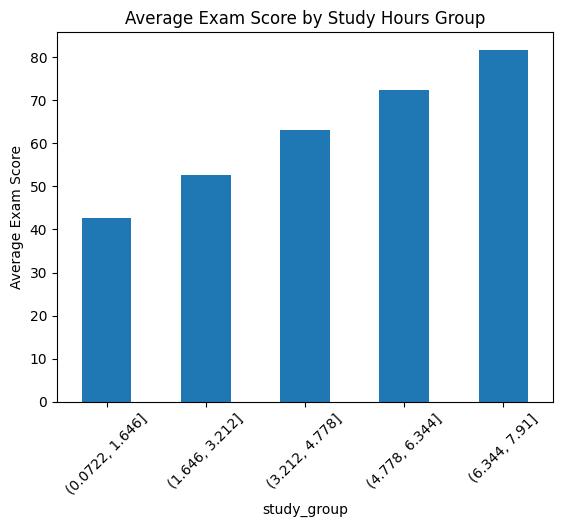

In [15]:

train["study_group"] = pd.cut(train["study_hours"], bins=5)


group_mean = train.groupby("study_group")["exam_score"].mean()

plt.figure()
group_mean.plot(kind="bar")
plt.title("Average Exam Score by Study Hours Group")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=45)
plt.show()


In [16]:
print(train["study_hours"].corr(train["exam_score"]))


0.7622673295024415


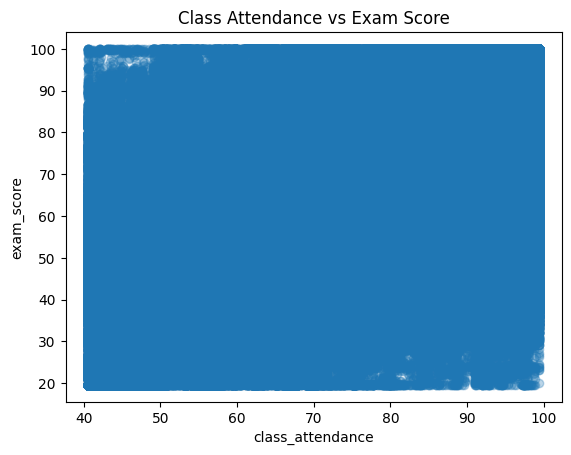

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.regplot(x="class_attendance", y="exam_score", data=train, scatter_kws={"alpha":0.3})
plt.title("Class Attendance vs Exam Score")
plt.show()


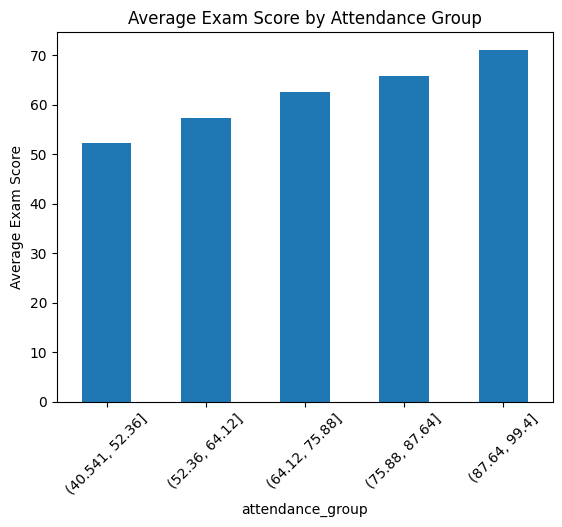

In [18]:
train["attendance_group"] = pd.cut(train["class_attendance"], bins=5)

attendance_mean = train.groupby("attendance_group")["exam_score"].mean()

plt.figure()
attendance_mean.plot(kind="bar")
plt.title("Average Exam Score by Attendance Group")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=45)
plt.show()


In [19]:
print("class_attendanceとの相関:")
print(train["class_attendance"].corr(train["exam_score"]))


class_attendanceとの相関:
0.3609540874687522


In [20]:
print(train.groupby("internet_access")["exam_score"].mean())


internet_access
no     62.478038
yes    62.509172
Name: exam_score, dtype: float64


In [21]:
print("ageとの相関:")
print(train["age"].corr(train["exam_score"]))


ageとの相関:
0.01047241129748402


In [22]:
print("sleep_hoursとの相関:")
print(train["sleep_hours"].corr(train["exam_score"]))


sleep_hoursとの相関:
0.16740997041768965


In [23]:
print(train.groupby("exam_difficulty")["exam_score"].mean())


exam_difficulty
easy        62.214401
hard        62.671693
moderate    62.606060
Name: exam_score, dtype: float64


In [24]:
print(train.groupby("gender")["exam_score"].mean())


gender
female    62.563220
male      62.175561
other     62.781191
Name: exam_score, dtype: float64


In [25]:
train["study_hours_sq"] = train["study_hours"] ** 2


In [26]:
train["study_attendance"] = train["study_hours"] * train["class_attendance"]
train["study_sleep"] = train["study_hours"] * train["sleep_hours"]


In [27]:
train["study_group"]
train["attendance_group"]


0           (87.64, 99.4]
1           (87.64, 99.4]
2           (87.64, 99.4]
3         (40.541, 52.36]
4          (75.88, 87.64]
               ...       
629995     (64.12, 75.88]
629996     (52.36, 64.12]
629997    (40.541, 52.36]
629998     (64.12, 75.88]
629999     (64.12, 75.88]
Name: attendance_group, Length: 630000, dtype: category
Categories (5, interval[float64, right]): [(40.541, 52.36] < (52.36, 64.12] < (64.12, 75.88] < (75.88, 87.64] < (87.64, 99.4]]

In [28]:
train = train.drop(["study_group", "attendance_group"], axis=1)


In [29]:
y = train["exam_score"]


In [30]:
X = train.drop(["exam_score", "id"], axis=1)


In [31]:
X = pd.get_dummies(X, drop_first=True)


In [32]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

model = Ridge(alpha=1.0)


In [33]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse = -scores.mean()

print("Ridge RMSE:", rmse)


Ridge RMSE: 8.892849784215139


In [34]:
for a in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=a)
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    print(f"alpha={a}, RMSE={-scores.mean()}")


alpha=0.01, RMSE=8.892849789860714
alpha=0.1, RMSE=8.892849789237127
alpha=1, RMSE=8.892849784215139
alpha=10, RMSE=8.892849855280353
alpha=100, RMSE=8.892862592234499


In [35]:
X.columns = X.columns.str.replace(r"[^A-Za-z0-9_]", "_", regex=True)

In [36]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

model_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

scores = cross_val_score(
    model_lgb,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_lgb = -scores.mean()

print("LightGBM RMSE:", rmse_lgb)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.503550
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.507092
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [37]:
model_lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

scores = cross_val_score(
    model_lgb,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Tuned LightGBM RMSE:", -scores.mean())


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011575 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.503550
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011529 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.507092
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [38]:
model_lgb.fit(X, y)

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model_lgb.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(15))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 26
[LightGBM] [Info] Start training from score 62.506672
                       feature  importance
1                  study_hours        9086
2             class_attendance        9084
5             study_attendance        5387
6                  study_sleep        4726
3                  sleep_hours        4391
0                          age        1924
4               study_hours_sq        1604
22         facility_rating_low        1495
17          sleep_quality_poor        1278
21     study_method_self_study        1256
16          sleep_quality_good        1104
20  study_method_online_videos        1049
18    study_method_group_study   

In [39]:
train["study_efficiency"] = train["study_hours"] / (train["sleep_hours"] + 1e-5)


In [40]:
train["study_per_attendance"] = train["study_hours"] / (train["class_attendance"] + 1e-5)


In [41]:
train["study_hours_cube"] = train["study_hours"] ** 3


In [42]:
y = train["exam_score"]

X = train.drop(["exam_score", "id"], axis=1)

X = pd.get_dummies(X, drop_first=True)
X.columns = X.columns.str.replace(r"[^A-Za-z0-9_]", "_", regex=True)


In [43]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

model_lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=50,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

scores = cross_val_score(
    model_lgb,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse = -scores.mean()

print("Advanced Feature LightGBM RMSE:", rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2134
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 29
[LightGBM] [Info] Start training from score 62.503550
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2131
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 29
[LightGBM] [Info] Start training from score 62.507092
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [44]:
important_features = [
    "study_hours",
    "class_attendance",
    "study_attendance",
    "study_sleep",
    "sleep_hours"
]

X_reduced = X[important_features]

scores = cross_val_score(
    model_lgb,
    X_reduced,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Reduced Feature RMSE:", -scores.mean())


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1071
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 5
[LightGBM] [Info] Start training from score 62.503550
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1070
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 5
[LightGBM] [Info] Start training from score 62.507092
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1070
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 5
[LightGBM] [Info] Start t

In [45]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score

In [46]:
import os
print(os.getcwd())

/kaggle/working


In [47]:
import os
print(os.listdir("/kaggle/input"))


['competitions']


In [48]:
import os
print(os.listdir("/kaggle/input/competitions"))


['playground-series-s6e1']


In [49]:
import os
print(os.listdir("/kaggle/input/competitions/playground-series-s6e1"))


['sample_submission.csv', 'train.csv', 'test.csv']


In [50]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score


In [51]:
DATA_PATH = "/kaggle/input/competitions/playground-series-s6e1/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (630000, 13)
Test shape: (270000, 12)


In [52]:
def create_features(df):
    df = df.copy()
    df["study_attendance"] = df["study_hours"] * df["class_attendance"]
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_hours_sq"] = df["study_hours"] ** 2
    return df

train = create_features(train)
test = create_features(test)

In [53]:
y = train["exam_score"]

X = train.drop(["exam_score", "id"], axis=1)
X_test = test.drop(["id"], axis=1)

In [54]:
X_all = pd.concat([X, X_test], axis=0)
X_all = pd.get_dummies(X_all, drop_first=True)
X_all.columns = X_all.columns.str.replace(r"[^A-Za-z0-9_]", "_", regex=True)

X = X_all.iloc[:len(train), :]
X_test = X_all.iloc[len(train):, :]

In [55]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [56]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

print("Final CV RMSE:", -scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.482335
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1372
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 26
[LightGBM] [Info] Start training from score 62.502155
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

In [57]:
model.fit(X, y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016018 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1370
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 26
[LightGBM] [Info] Start training from score 62.506672


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
              num_leaves=50, random_state=42, subsample=0.8)

In [58]:
pred = model.predict(X_test)

In [59]:
submission = pd.DataFrame({
    "id": test["id"],
    "exam_score": pred
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("submission.csv 作成完了（/kaggle/working に保存）")

submission.csv 作成完了（/kaggle/working に保存）
